# 03 Qualitative — Word Association Clustering (Q9)

Prototype: embed `word_1`–`word_5` with `sentence-transformers`, cluster with `AgglomerativeClustering` (cosine distance), inspect groups.

In [36]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('').resolve()))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
import utils as U


## 1. Load data

In [37]:
DATA = pathlib.Path('..') / 'data'
df_raw = pd.read_excel(DATA / 'quality_analisys.xlsx')

word_cols = ['word_1', 'word_2', 'word_3', 'word_4', 'word_5']

# Flatten → unique words (lowercase)
words_flat = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
)
unique_words = sorted(words_flat.unique())
print(f'Total tokens: {len(words_flat)}  |  Unique: {len(unique_words)}')
print(unique_words[0:])


Total tokens: 278  |  Unique: 151
['-', 'abundant', 'accessibility', 'accordance', 'accuracy', 'afirmative', 'amount', 'analysis', 'anotation', 'anova', 'approximation', 'autorization', 'availability', 'avaliation', 'balance', 'balancing', 'bias', 'business', 'cheap', 'clarity', 'cleaning', 'coherence', 'cohesion', 'collect', 'complete data', 'completeness', 'compliance', 'comprehensibility', 'comprehensiblity', 'consistency', 'correctness', 'credibility', 'current', 'data analysis', 'data bank', 'dataleakage', 'dataset', 'dependency', 'desbalancing', 'descriptive', 'determination', 'distinction', 'distribution', 'diversity', 'duplication', 'eda', 'effectiveness', 'efficiency', 'encoder', 'enough data', 'especialists', 'essential', 'expensive', 'explainability', 'filters', 'format', 'formatted', 'foundation', 'granularity', 'identifiable', 'iid', 'important', 'incompleteness', 'inconsistency', 'incorrect', 'indefined', 'indispensable', 'information', 'integration', 'integrity', 'interd

## 2. Embed with sentence-transformers

In [38]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(unique_words, normalize_embeddings=True)
print('Embedding matrix:', embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding matrix: (151, 384)


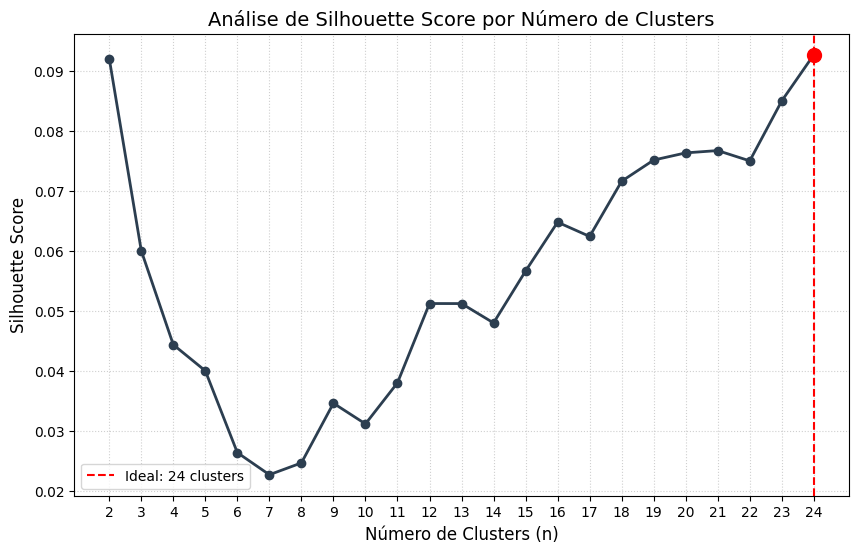


O número ideal de clusters parece ser: 24 com score de 0.0926


In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

# --- Seu código original com pequenos ajustes para o gráfico ---
dist_matrix = np.clip(1 - cosine_similarity(embeddings), 0, None)
range_n_clusters = range(2, 25)
scores = [] # Lista para armazenar os resultados

melhor_n = 2
melhor_score = -1

for n in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage='average')
    preds = clusterer.fit_predict(dist_matrix)
    
    score = silhouette_score(dist_matrix, preds, metric='precomputed')
    scores.append(score) # Salva o score para o gráfico
    
    if score > melhor_score:
        melhor_score = score
        melhor_n = n

# --- Código para gerar o gráfico ---
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, scores, marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# Destacando o melhor ponto
plt.axvline(x=melhor_n, color='red', linestyle='--', label=f'Ideal: {melhor_n} clusters')
plt.scatter(melhor_n, melhor_score, color='red', s=100, zorder=5)

# Estilização
plt.title('Análise de Silhouette Score por Número de Clusters', fontsize=14)
plt.xlabel('Número de Clusters (n)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(range_n_clusters)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

print(f"\nO número ideal de clusters parece ser: {melhor_n} com score de {melhor_score:.4f}")

## 3. Agglomerative clustering (cosine distance)

In [40]:
N_CLUSTERS = 12

clust = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric='precomputed',
    linkage='average',
)
labels = clust.fit_predict(dist_matrix)

word_df = pd.DataFrame({'word': unique_words, 'cluster': labels})
word_df.sort_values(['cluster', 'word'], inplace=True)
print(word_df['cluster'].value_counts().sort_index())


cluster
0      7
1      4
2     48
3     44
4     10
5      7
6      2
7      3
8     17
9      3
10     5
11     1
Name: count, dtype: int64


## 4. Inspect clusters

In [41]:
for cid, grp in word_df.groupby('cluster'):
    print(f'-- Cluster {cid} ({len(grp)} words) --')
    print('  ', ', '.join(grp['word'].tolist()))
    print()


-- Cluster 0 (7 words) --
   cleaning, cohesion, collect, duplication, reuse, sanitize, split

-- Cluster 1 (4 words) --
   anova, distribution, integration, variance

-- Cluster 2 (48 words) --
   abundant, accuracy, approximation, availability, balance, balancing, bias, clarity, completeness, compliance, consistency, correctness, credibility, desbalancing, descriptive, determination, distinction, diversity, effectiveness, efficiency, explainability, granularity, identifiable, incompleteness, inconsistency, incorrect, information, integrity, measurement, performace, performance, precision, quality, relevance, reliability, reliable, representativeness, scalability, scale, security, stability, standartise, streaming, subjectivity, technique, validade, validate, validation

-- Cluster 3 (44 words) --
   accordance, afirmative, amount, anotation, avaliation, business, cheap, current, dependency, eda, essential, expensive, foundation, iid, important, indefined, indispensable, investiment, 

## 5. Frequency within each cluster

In [42]:
freq = words_flat.value_counts().rename_axis('word').reset_index(name='freq')

word_freq = word_df.merge(freq, on='word', how='left').fillna({'freq': 0})
word_freq['freq'] = word_freq['freq'].astype(int)

for cid, grp in word_freq.groupby('cluster'):
    top = grp.nlargest(5, 'freq')[['word', 'freq']]
    items = ', '.join(f"{r.word} ({r.freq})" for r in top.itertuples())
    print(f'Cluster {cid}: {items}')


Cluster 0: cleaning (5), reuse (2), cohesion (1), collect (1), duplication (1)
Cluster 1: distribution (4), integration (2), anova (1), variance (1)
Cluster 2: completeness (15), consistency (15), precision (10), reliability (10), relevance (9)
Cluster 3: update (6), volume (5), amount (4), current (3), source (3)
Cluster 4: normalization (5), standardization (4), autorization (1), encoder (1), format (1)
Cluster 5: comprehensibility (2), coherence (1), comprehensiblity (1), especialists (1), interdisciplinarity (1)
Cluster 6: - (1), read_me (1)
Cluster 7: multicollinearity (1), relation (1), symmetry (1)
Cluster 8: outliers (4), noise (2), processing (2), signal (2), analysis (1)
Cluster 9: null (1), null data (1), nullity (1)
Cluster 10: traceability (3), accessibility (2), outliners (1), transferability (1), transparency (1)
Cluster 11: rastreabilidade (1)


## 6. Cosine similarity heatmap (cluster centroids)

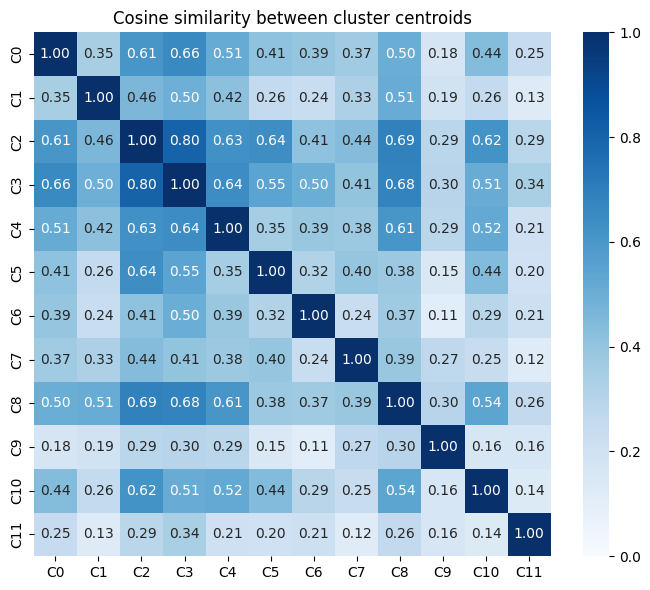

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

centroids = np.stack([
    embeddings[labels == c].mean(axis=0)
    for c in range(N_CLUSTERS)
])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)

sim_matrix = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sim_matrix,
    annot=True, fmt='.2f',
    vmin=0, vmax=1,
    xticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
    yticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
    cmap='Blues', ax=ax,
)
ax.set_title('Cosine similarity between cluster centroids')
plt.tight_layout()
pathlib.Path('../figures').mkdir(exist_ok=True)
plt.savefig('../figures/q9_cluster_similarity.pdf', dpi=150, bbox_inches='tight')
plt.show()


## 7. Save cluster assignments

In [44]:
out_path = DATA / 'processed' / 'q9_word_clusters.csv'
word_freq.sort_values(['cluster', 'freq'], ascending=[True, False]).to_csv(out_path, index=False)
print('Saved:', out_path)


Saved: ..\data\processed\q9_word_clusters.csv


## 8. Manual cluster label map

Run the helper below to see top-words per cluster, then fill `CLUSTER_LABELS` with a short English label.
Update this cell whenever you change `N_CLUSTERS` and re-run clustering.

In [45]:
# Helper: print the dict template with top words as hints (re-run after changing N_CLUSTERS)
def _print_label_hints(word_freq, n_clusters):
    print('CLUSTER_LABELS = {')
    for cid in range(n_clusters):
        grp = word_freq[word_freq['cluster'] == cid]
        top = ', '.join(grp.nlargest(4, 'freq')['word'].tolist())
        print(f'    {cid}: "",  # {top}')
    print('}')

_print_label_hints(word_freq, N_CLUSTERS)


CLUSTER_LABELS = {
    0: "",  # cleaning, reuse, cohesion, collect
    1: "",  # distribution, integration, anova, variance
    2: "",  # completeness, consistency, precision, reliability
    3: "",  # update, volume, amount, current
    4: "",  # normalization, standardization, autorization, encoder
    5: "",  # comprehensibility, coherence, comprehensiblity, especialists
    6: "",  # -, read_me
    7: "",  # multicollinearity, relation, symmetry
    8: "",  # outliers, noise, processing, signal
    9: "",  # null, null data, nullity
    10: "",  # traceability, accessibility, outliners, transferability
    11: "",  # rastreabilidade
}


In [46]:
# Fill in a label for each cluster ID.
# Keys must cover 0 .. N_CLUSTERS-1; missing keys fall back to 'Cluster N'.
CLUSTER_LABELS = {
    0: "Data Quality Dimensions",
    1: "Data Preparation",
    2: "Understandability / RE",
    3: "Statistical Analysis",
    4: "Missing Data",
    5: "Traceability",
    6: "Noise / Artifacts",
    7: "Data Relationships",
}


## 9. Top-mind words â€” by semantic cluster and position

Stacked horizontal bars: each bar = one cluster (labeled), stacks = word positions 1-5.
Robust to any value of `N_CLUSTERS`.

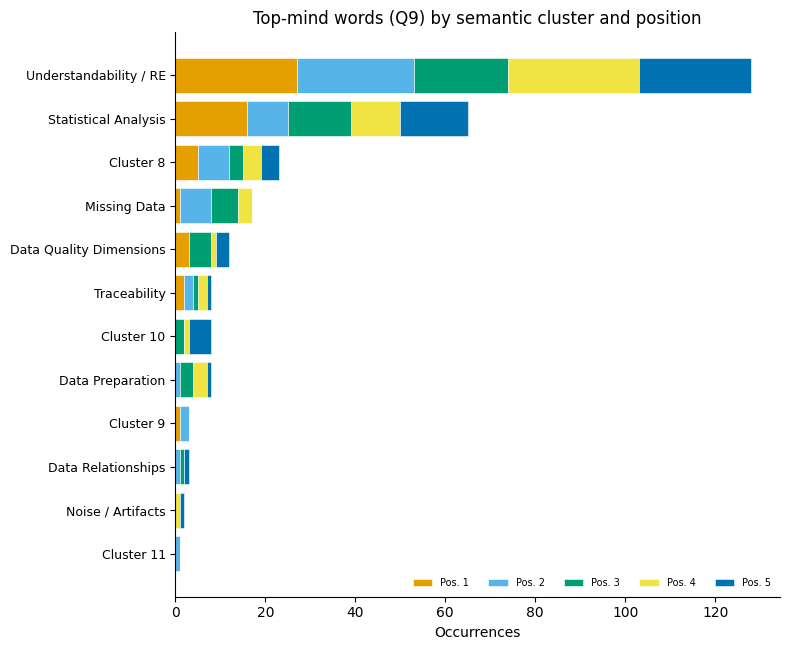

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# --- rebuild (word, position) from raw data ---
word_pos = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
    .reset_index()
)
word_pos.columns = ['resp_idx', 'word_col', 'word']
word_pos['position'] = word_pos['word_col'].str.extract(r'(\d+)').astype(int)

# --- merge cluster assignment ---
word_pos = word_pos.merge(word_df[['word', 'cluster']], on='word', how='left')
word_pos['label'] = word_pos['cluster'].map(
    lambda c: CLUSTER_LABELS.get(int(c), f'Cluster {int(c)}') if pd.notna(c) else 'Unknown'
)

# --- aggregate: count per (label, position) ---
agg = (
    word_pos.groupby(['label', 'position'])
    .size()
    .unstack(fill_value=0)
)
pos_cols = sorted(agg.columns)

# sort clusters by total occurrences (ascending so largest is at top)
agg = agg.loc[agg.sum(axis=1).sort_values(ascending=True).index]

# --- plot ---
try:
    colors = U.PALETTE_WONG[1 : len(pos_cols) + 1]
except Exception:
    colors = plt.cm.tab10.colors[: len(pos_cols)]

fig, ax = plt.subplots(figsize=(8, max(3, len(agg) * 0.55)))
y = np.arange(len(agg))
bottom = np.zeros(len(agg))

for i, pos in enumerate(pos_cols):
    width = agg[pos].values
    ax.barh(y, width, left=bottom,
            color=colors[i % len(colors)],
            edgecolor='white', linewidth=0.4,
            label=f'Pos. {pos}')
    bottom += width

ax.set_yticks(y)
ax.set_yticklabels(agg.index, fontsize=9)
ax.set_xlabel('Occurrences')
ax.set_title('Top-mind words (Q9) by semantic cluster and position')
ax.legend(loc='lower right', frameon=False,
          ncol=len(pos_cols), fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

pathlib.Path('../figures').mkdir(exist_ok=True)
plt.savefig('../figures/q9_top_mind_words.pdf', dpi=150, bbox_inches='tight')
plt.show()
